# Block 4 — Hyperparameter Tuning with Optuna

**Goals for this block:**

- Learn automated hyperparameter optimization with **Optuna**
- Tune a **Temporal Convolutional Network (TCN)** model
- Find optimal parameters for **TCN** with **future covariates**: calendar features (hour, day-of-week, month)
- Compare performance improvements through systematic tuning

## 0. Environment & Imports

In [ ]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
tf.config.set_logical_device_configuration(gpus[0], [tf.config.LogicalDeviceConfiguration(memory_limit=6500)])

import torch
assert torch.cuda.is_available()
torch.cuda.set_per_process_memory_fraction(0.3)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler

from darts.dataprocessing.transformers import Scaler
from darts.utils.missing_values import fill_missing_values


## 1. Preprocessing function

We'll reuse our preprocessing function from previous blocks to maintain consistency across our experiments.

In [ ]:
def preprocessing_data_with_DARTS(series,
                      resample_freq='h', agg_method='mean',
                      missing_strategy='linear', 
                      scaling_method='standard',
                      train_ratio=0.7, val_ratio=0.15):
    """
    Complete time series preprocessing pipeline using Darts library.
        
    Returns: train, train_y, val, val_y, test, test_y, scaler
    """

    # 1. Handle missing values
    filled_series = fill_missing_values(series, method=missing_strategy)

    # 2. Resample data
    resampled_series = filled_series.resample(resample_freq, method=agg_method)
    
    # 3. Time-aware split
    
    # Calculate split points
    total_len = len(resampled_series)
    train_end = int(total_len * train_ratio)
    val_end = int(total_len * (train_ratio + val_ratio))
    
    # Split the series
    train_series = resampled_series[:train_end]
    val_series = resampled_series[train_end:val_end]
    test_series = resampled_series[val_end:]

    # 4. Scaling (fit only on training data)
    if scaling_method == 'standard':
        scaler = StandardScaler()
    elif scaling_method == 'minmax':
        scaler = MinMaxScaler()
    elif scaling_method == 'robust':
        scaler = RobustScaler()
    else:
        raise ValueError(f"Unsupported scaling method: {scaling_method}")
        
    scaler = Scaler(scaler)
    
    # Fit on training data and transform all sets
    scaler.fit(train_series)
    train_scaled = scaler.transform(train_series)
    val_scaled = scaler.transform(val_series)
    test_scaled = scaler.transform(test_series)
    
    # 5. WINDOWING
    ######## NOT NEEDED WITH DARTS MODELS ##########

    return train_scaled, val_scaled, test_scaled, scaler

## 2. Load & Prepare Data

Load the electricity consumption dataset and prepare it for time series forecasting.

In [4]:
from darts.datasets import ElectricityConsumptionZurichDataset

series = ElectricityConsumptionZurichDataset().load() 
target_columns = ["Value_NE5", "Value_NE7"]
covariate_columns = ['Hr [%Hr]', 'RainDur [min]', 'StrGlo [W/m2]', 'T [°C]', 'WD [°]', 'WVs [m/s]', 'WVv [m/s]', 'p [hPa]']

# splt the time series into target and covariates
target_series = series[target_columns]
past_covariates = series[covariate_columns]


<div style="background-color: #ffedcc; border-left: 6px solid #ff7518; padding: 10px; margin-bottom: 10px;">
<h2>📝 Exercise: Prepare data for training</h2>

1. Preprocess the dataset using our preprocessing pipeline


</div>

#### 2.1 Basic Preprocessing

Apply our standard preprocessing pipeline to the electricity data.

⚠️: We will be tuning a TCN model which takes past covariates. Think of preprocessing target and past covariate series

In [ ]:
train_target, val_target, test_target, scaler_target = preprocessing_data_with_DARTS(target_series,
                                              resample_freq='h', agg_method='sum',
                                              missing_strategy='linear', 
                                              scaling_method='standard',
                                              train_ratio=0.7, val_ratio=0.15)

train_past_cov, val_past_cov, test_past_cov, scaler_past_cov = preprocessing_data_with_DARTS(past_covariates,
                                              resample_freq='h', agg_method='sum',
                                              missing_strategy='linear', 
                                              scaling_method='standard',
                                              train_ratio=0.7, val_ratio=0.15)

<div style="background-color: #ffedcc; border-left: 6px solid #ff7518; padding: 10px; margin-bottom: 10px;">
<h2>📝 Exercise: Hyperparameter Optimization with Optuna</h2>

Learn how to systematically find the best model configuration using Optuna's optimization framework.

1. Build the objective function that defines what to optimize

2. Run a tuning job to find optimal hyperparameters

This exercise will teach you automated hyperparameter optimization for time series models.

</div>

### 1. **Study**: The optimization session
```python
study = optuna.create_study(direction="minimize", study_name="LSTM_sMAPE")
```
- `direction`: "minimize" (for loss/error) or "maximize" (for accuracy)
- `study_name`: Identifier for tracking experiments

#### 2. **Trial**: Single hyperparameter configuration attempt
```python
def objective_lstm(trial):
    # Suggest hyperparameter values
    window_size = 24 * trial.suggest_int("window_size_factor", 1, 7)
    hidden_dim = trial.suggest_categorical("hidden_dim", [32, 64, 96, 128])
    
    # Train model with suggested parameters
    model = RNNModel(input_chunk_length=window_size, hidden_dim=hidden_dim, ...)
    
    # Return metric to optimize
    return validation_error
```

#### 3. **Hyperparameter Suggestion Methods**

| Method | Use Case | Example |
|--------|----------|---------|
| `suggest_int(name, low, high)` | Integer ranges | `trial.suggest_int("layers", 1, 5)` |
| `suggest_float(name, low, high)` | Continuous values | `trial.suggest_float("lr", 1e-5, 1e-1, log=True)` |
| `suggest_categorical(name, choices)` | Discrete choices | `trial.suggest_categorical("optimizer", ["adam", "sgd"])` |
| `suggest_uniform(name, low, high)` | Uniform distribution | `trial.suggest_uniform("dropout", 0.1, 0.5)` |


### 3.2 TCN Objective Function
Define the objective function for optimizing our Temporal Convolutional Network.

In [6]:
# Fixed forecast horizon for all experiments
forecast_horizon = 24

Suggestion: TCN Hyperparameters to be tuned:

- `input_chunk_length`: How many past timesteps to use (4-10 days)
- `num_filters`: Number of convolutional filters (2, 4, 16)
- `kernel_size`: Size of convolutional kernels (3 to 11)
- `dilation_base`: Base for exponential dilation (2 to 4)

In [8]:
from darts.models import TCNModel
from darts.metrics import smape

# 1. Build the objective function
def objective_tcn(trial):
    model = TCNModel(
                input_chunk_length=24 * trial.suggest_int("input_length_factor", 4, 10),
                output_chunk_length=forecast_horizon,
                num_filters=trial.suggest_categorical("num_filters", [2, 4, 16]),
                kernel_size=trial.suggest_int("kernel_size", 3, 11, step=2),
                dilation_base=trial.suggest_int("dilation_base", 2, 4),
                dropout=0.3,
                batch_size=256,
                n_epochs=5,
                pl_trainer_kwargs={"accelerator": "gpu"},
                random_state=42
            )

    # Train the model without using validation covariates
    model.fit(
        series=train_target, 
        past_covariates=train_past_cov,
        epochs=10,
        verbose=False)
    
    # Generate historical forecasts on validation set
    pred_series = model.historical_forecasts(series=val_target,
                                            past_covariates=val_past_cov,
                                            forecast_horizon=forecast_horizon, 
                                            retrain=False, 
                                            last_points_only=True)
    
    # Inverse transform predictions and targets
    pred_unscaled = scaler_target.inverse_transform(pred_series)
    val_unscaled = scaler_target.inverse_transform(val_target)

    # Calculate and return sMAPE
    smape_score = smape(pred_unscaled, val_unscaled)
    return smape_score

/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/fs/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore


## 4. Running Optimization Studies

Execute the hyperparameter optimization and analyze results.

### 4.1 Optimize TCN Parameters

In [9]:
import optuna

study_tcn = optuna.create_study(direction="minimize", study_name="TCN_SMAPE")
study_tcn.optimize(objective_tcn, n_trials=15, show_progress_bar=True)
print("Best TCN sMAPE:", round(study_tcn.best_value, 4))
print(study_tcn.best_trial.params)


[I 2025-11-10 16:36:25,551] A new study created in memory with name: TCN_SMAPE
  0%|          | 0/15 [00:00<?, ?it/s]GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
`Trainer.fit` stopped: `max_epochs=10` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Best trial: 0. Best value: 5.83811:   7%|▋         | 1/15 [00:19<04:36, 19.78s/it]GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument

[I 2025-11-10 16:36:45,342] Trial 0 finished with value: 5.8381147384643555 and parameters: {'input_length_factor': 4, 'num_filters': 4, 'kernel_size': 3, 'dilation_base': 2}. Best is trial 0 with value: 5.8381147384643555.


`Trainer.fit` stopped: `max_epochs=10` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Best trial: 1. Best value: 3.87088:  13%|█▎        | 2/15 [00:50<05:43, 26.42s/it]GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


[I 2025-11-10 16:37:16,406] Trial 1 finished with value: 3.870878219604492 and parameters: {'input_length_factor': 10, 'num_filters': 4, 'kernel_size': 11, 'dilation_base': 2}. Best is trial 1 with value: 3.870878219604492.


`Trainer.fit` stopped: `max_epochs=10` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Best trial: 1. Best value: 3.87088:  20%|██        | 3/15 [01:18<05:21, 26.77s/it]GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


...

[I 2025-11-10 16:42:39,053] Trial 12 finished with value: 3.73492693901062 and parameters: {'input_length_factor': 10, 'num_filters': 16, 'kernel_size': 9, 'dilation_base': 3}. Best is trial 8 with value: 3.6595664024353027.


`Trainer.fit` stopped: `max_epochs=10` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Best trial: 8. Best value: 3.65957:  93%|█████████▎| 14/15 [06:52<00:36, 36.17s/it]GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


[I 2025-11-10 16:43:18,046] Trial 13 finished with value: 3.881103038787842 and parameters: {'input_length_factor': 9, 'num_filters': 16, 'kernel_size': 7, 'dilation_base': 3}. Best is trial 8 with value: 3.6595664024353027.


`Trainer.fit` stopped: `max_epochs=10` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Best trial: 8. Best value: 3.65957: 100%|██████████| 15/15 [07:23<00:00, 29.56s/it]

[I 2025-11-10 16:43:48,898] Trial 14 finished with value: 4.18446683883667 and parameters: {'input_length_factor': 8, 'num_filters': 16, 'kernel_size': 9, 'dilation_base': 3}. Best is trial 8 with value: 3.6595664024353027.
Best TCN sMAPE: 3.6596
{'input_length_factor': 9, 'num_filters': 16, 'kernel_size': 3, 'dilation_base': 2}


### 4.2 Analyze Optimization Results
Review all trials to understand hyperparameter impact on performance. 

`value`refers to the metric you choose to optimize (in this case sMAPE)

In [10]:
df_results = study_tcn.trials_dataframe().sort_values("value")
df_results.head(15)

,number,value,datetime_start,datetime_complete,duration,params_dilation_base,params_input_length_factor,params_kernel_size,params_num_filters,state
8,8,3.659566,2025-11-10 16:39:42.910424,2025-11-10 16:40:25.326849,0 days 00:00:42.416425,2,9,3,16,COMPLETE
11,11,3.734927,2025-11-10 16:41:15.292046,2025-11-10 16:41:57.155362,0 days 00:00:41.863316,3,10,9,16,COMPLETE
12,12,3.734927,2025-11-10 16:41:57.156782,2025-11-10 16:42:39.053105,0 days 00:00:41.896323,3,10,9,16,COMPLETE
1,1,3.870878,2025-11-10 16:36:45.343786,2025-11-10 16:37:16.406301,0 days 00:00:31.062515,2,10,11,4,COMPLETE
13,13,3.881103,2025-11-10 16:42:39.054445,2025-11-10 16:43:18.046035,0 days 00:00:38.991590,3,9,7,16,COMPLETE
10,10,4.184467,2025-11-10 16:40:44.258730,2025-11-10 16:41:15.290514,0 days 00:00:31.031784,3,8,9,16,COMPLETE
14,14,4.184467,2025-11-10 16:43:18.047542,2025-11-10 16:43:48.898817,0 days 00:00:30.851275,3,8,9,16,COMPLETE
5,5,4.388311,2025-11-10 16:38:33.539499,2025-11-10 16:39:03.086545,0 days 00:00:29.547046,4,9,5,4,COMPLETE
2,2,4.960210,2025-11-10 16:37:16.407780,2025-11-10 16:37:43.604709,0 days 00:00:27.196929,2,7,3,4,COMPLETE
7,7,5.012705,2025-11-10 16:39:23.595549,2025-11-10 16:39:42.908909,0 days 00:00:19.313360,2,4,5,16,COMPLETE


This table shows:

- value: Validation metric sMAPE (lower is better)

- params_*: Hyperparameter values for each trial

- Results sorted by performance (best first)

## 5. Final Evaluation on Test

Let's evaluate our best model and compare its performance with the TCN model from BLOCK 3

### 5.1 Train Best Model on Full Training Data


In [ ]:
from darts.metrics import mae

# Rebuild the best model from the best trial
best_tcn = TCNModel(
            input_chunk_length=24 * study_tcn.best_trial.params["input_length_factor"],
            output_chunk_length=forecast_horizon,
            num_filters=study_tcn.best_trial.params["num_filters"],
            kernel_size=study_tcn.best_trial.params["kernel_size"],
            dilation_base=study_tcn.best_trial.params["dilation_base"],
            dropout=0.3,
            batch_size=256,
            pl_trainer_kwargs={"accelerator": "gpu"}
        )

# Combine train and validation for final training
trainval_target = train_target.append(val_target)
trainval_past_cov = train_past_cov.append(val_past_cov)

# Train final models on train+val data
best_tcn.fit(series=trainval_target, 
             past_covariates=trainval_past_cov,
             epochs=10,
             verbose=False)


# Make predictions on test set
pred_tcn = best_tcn.historical_forecasts(series=test_target, past_covariates=test_past_cov , 
                                         forecast_horizon=forecast_horizon, retrain=False, last_points_only=True)

# Inverse transform predictions and test data
pred_tcn_unscaled = scaler_target.inverse_transform(pred_tcn)
test_unscaled = scaler_target.inverse_transform(test_target)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
`Trainer.fit` stopped: `max_epochs=10` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


### 5.2 Performance Analysis & Visualization


In [12]:
# Calculate MAE, RMSE, MAPE, sMAPE

from darts.metrics import mae, rmse, mape, smape

evaluation_metrics_tcn = {
    "MAE": mae(test_unscaled, pred_tcn_unscaled),
    "RMSE": rmse(test_unscaled, pred_tcn_unscaled),
    "MAPE": mape(test_unscaled, pred_tcn_unscaled),
    "sMAPE": smape(test_unscaled, pred_tcn_unscaled),
}
print(evaluation_metrics_tcn)

{'MAE': 5755.0234, 'RMSE': 9759.859, 'MAPE': 3.7578797, 'sMAPE': 3.8511515}


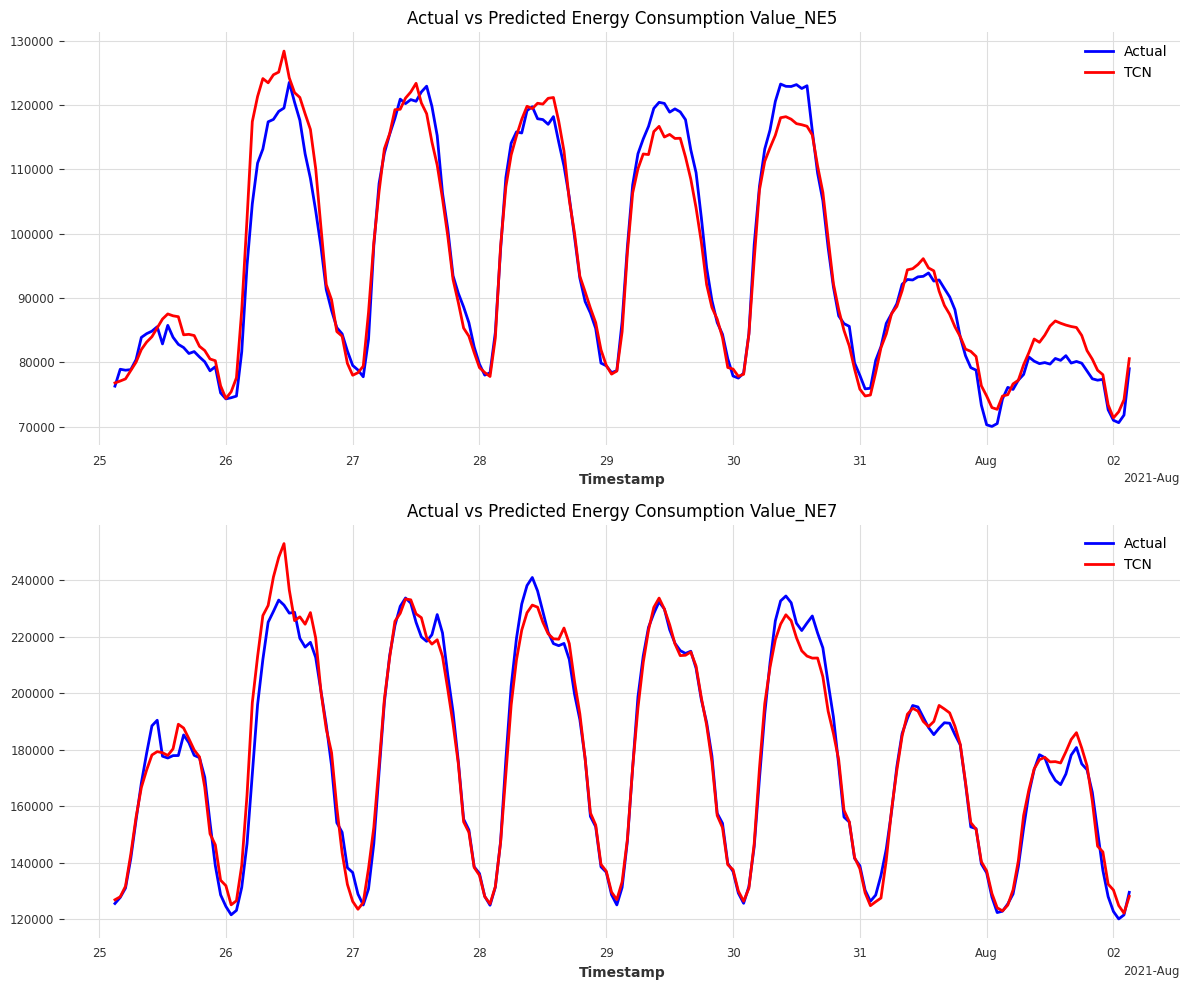

In [13]:
# Plotting some predictions vs actuals
start_idx = pd.Timestamp('2021-07-25 03:00:00')
end_idx = pd.Timestamp('2021-08-02 03:00:00')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
test_unscaled[target_columns[0]][start_idx:end_idx].plot(label="Actual", color='blue', ax=ax1)
pred_tcn_unscaled[target_columns[0]][start_idx:end_idx].plot(label="TCN", color='red', title=f"Actual vs Predicted Energy Consumption {target_columns[0]}", ax=ax1)

test_unscaled[target_columns[1]][start_idx:end_idx].plot(label="Actual", color='blue', ax=ax2)
pred_tcn_unscaled[target_columns[1]][start_idx:end_idx].plot(label="TCN", color='red', title=f"Actual vs Predicted Energy Consumption {target_columns[1]}", ax=ax2)

ax1.legend()
ax2.legend()
plt.tight_layout()
plt.show()

## ✅ Summary

## What You've Accomplished:

- Automated Hyperparameter Optimization: Used Optuna to systematically find optimal model configurations

- TCN Model Tuning: Optimized Temporal Convolutional Network parameters for time series forecasting

- Performance Comparison: Evaluated improvements from systematic tuning vs. manual parameter selection
